In [ ]:
import pandas as pd
from pathlib import Path

ep_dir = Path("/home/icub/mujoco_ws/REPO_ICUB/outputs/tests/eval_2026-03-11_12-38-08/episode_000")

obs_df = pd.read_csv(ep_dir / "observations.csv")
act_df = pd.read_csv(ep_dir / "actions.csv")

# Merge on 'step' column into a single DataFrame
df = obs_df.merge(act_df, on="step", suffixes=("_obs", "_act"))

print(f"Observations: {obs_df.shape}  |  Actions: {act_df.shape}  |  Combined: {df.shape}")
df["object_pos_x"] #.head()

Observations: (600, 100)  |  Actions: (600, 12)  |  Combined: (600, 111)


,step,torso_pitch,torso_roll,torso_yaw,r_shoulder_pitch,r_shoulder_roll,r_shoulder_yaw,r_elbow,r_wrist_prosup,r_wrist_pitch,...,rh_pos_y,rh_pos_z,rh_quat_w,rh_quat_x,rh_quat_y,rh_quat_z,rh_gripper,gaze_x,gaze_y,gaze_z
0,0,0.003609,0.000463,-0.002473,-0.346313,0.429962,0.002317,1.216365,0.001062,-0.001411,...,-0.137347,0.689489,-0.541289,0.827214,0.025205,0.040122,0.029283,1.481192,-0.208987,0.646601
1,1,0.001827,0.001027,0.002037,-0.343877,0.424434,0.005599,1.212797,-0.000488,0.005821,...,-0.136647,0.690903,-0.547652,0.825045,0.028751,0.044732,0.019406,1.477793,-0.219238,0.644031
2,2,-0.000202,0.001217,0.002421,-0.345639,0.424325,0.004699,1.211343,0.000426,0.003883,...,-0.136721,0.689889,-0.545954,0.827802,0.026110,0.046313,0.022100,1.476274,-0.222254,0.642204
3,3,0.000699,0.001003,0.000264,-0.348191,0.427618,0.002487,1.213825,0.000139,-0.001700,...,-0.138215,0.690076,-0.544878,0.829614,0.026884,0.047390,0.021465,1.474763,-0.226587,0.643969
4,4,0.003303,0.000735,-0.001317,-0.350861,0.430293,0.004248,1.215070,0.000424,-0.003001,...,-0.138243,0.689608,-0.548250,0.826059,0.028258,0.048883,0.021313,1.472174,-0.229867,0.641792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,595,-0.014591,-0.000882,0.063843,-0.526124,0.731980,0.177295,1.251732,-0.632649,0.097339,...,-0.199852,0.780160,-0.702809,0.695190,0.093598,0.100758,0.041753,1.338189,-0.686039,0.709416
596,596,-0.014597,-0.000881,0.063847,-0.526124,0.731975,0.177273,1.251766,-0.632670,0.097337,...,-0.200122,0.780251,-0.706996,0.691346,0.096022,0.099383,0.009316,1.338744,-0.687848,0.711881
597,597,-0.014597,-0.000879,0.063848,-0.526133,0.731981,0.177268,1.251796,-0.632681,0.097329,...,-0.199664,0.777546,-0.700746,0.697507,0.095187,0.100358,0.149894,1.341124,-0.681926,0.706409
598,598,-0.014615,-0.000878,0.063846,-0.526124,0.731993,0.177260,1.251825,-0.632677,0.097306,...,-0.200085,0.781104,-0.709898,0.690003,0.096897,0.100812,0.018049,1.343049,-0.677000,0.723619


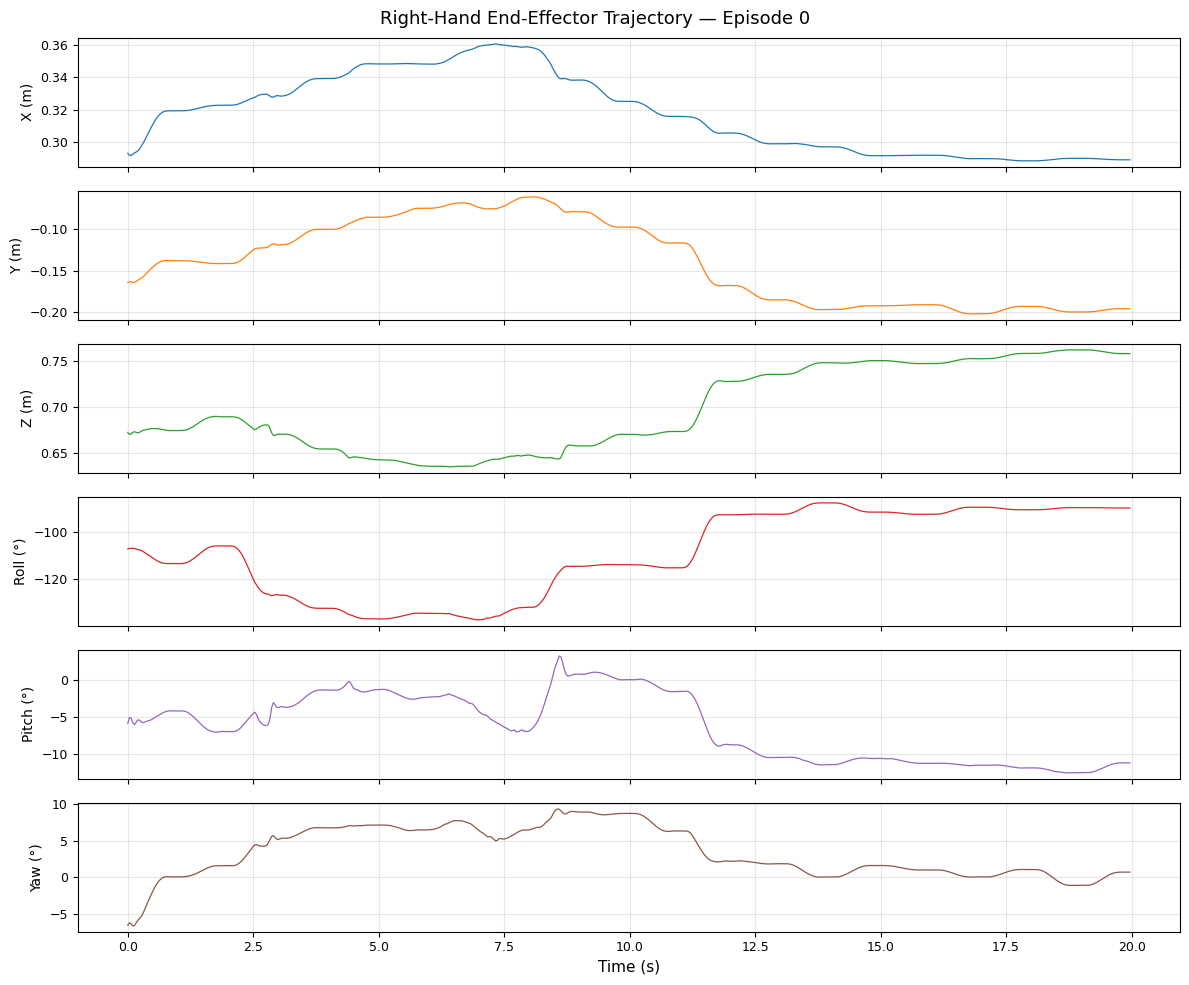

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

# --- End-effector position ---
ee_pos = df[["rh_ee_pos_x", "rh_ee_pos_y", "rh_ee_pos_z"]].values

# --- Quaternion → Roll / Pitch / Yaw (degrees) ---
ee_quat_wxyz = df[["rh_ee_quat_w", "rh_ee_quat_x", "rh_ee_quat_y", "rh_ee_quat_z"]].values
# scipy expects [x, y, z, w]
ee_quat_xyzw = ee_quat_wxyz[:, [1, 2, 3, 0]]
rpy_deg = Rotation.from_quat(ee_quat_xyzw).as_euler("xyz", degrees=True)

fps = 30
time_s = df["step"].values / fps

# --- Plot ---
labels = ["X (m)", "Y (m)", "Z (m)", "Roll (°)", "Pitch (°)", "Yaw (°)"]
data   = [ee_pos[:, 0], ee_pos[:, 1], ee_pos[:, 2],
          rpy_deg[:, 0], rpy_deg[:, 1], rpy_deg[:, 2]]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

fig, axes = plt.subplots(6, 1, figsize=(12, 10), sharex=True)
for ax, y, label, c in zip(axes, data, labels, colors):
    ax.plot(time_s, y, color=c, linewidth=0.9)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=9)

axes[-1].set_xlabel("Time (s)", fontsize=11)
fig.suptitle("Right-Hand End-Effector Trajectory — Episode 0", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

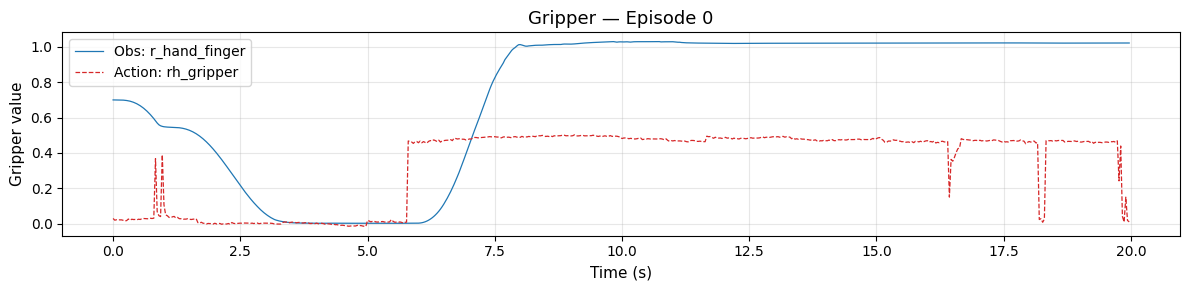

In [4]:
fig, ax = plt.subplots(figsize=(12, 3))

ax.plot(time_s, df["r_hand_finger"].values, color="#1f77b4", linewidth=0.9, label="Obs: r_hand_finger")
ax.plot(time_s, df["rh_gripper"].values, color="#d62728", linewidth=0.9, linestyle="--", label="Action: rh_gripper")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Gripper value", fontsize=11)
ax.set_title("Gripper — Episode 0", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

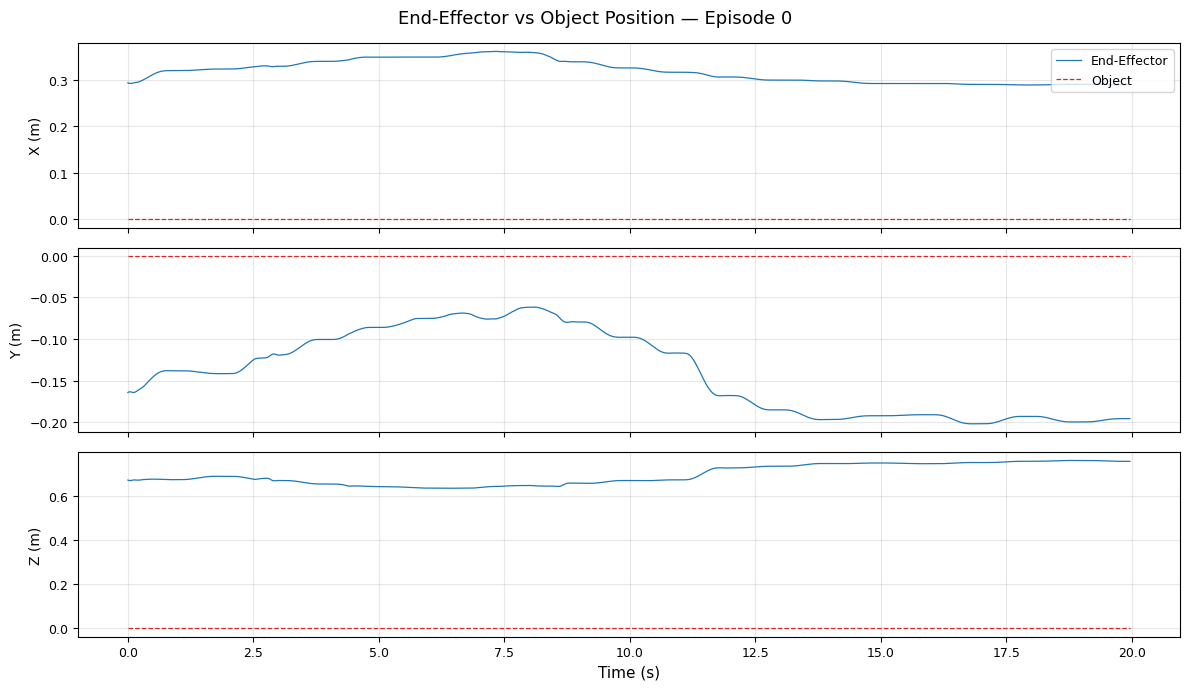

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for i, axis_label in enumerate(["x", "y", "z"]):
    ee_col  = f"rh_ee_pos_{axis_label}"
    obj_col = f"object_pos_{axis_label}"

    axes[i].plot(time_s, df[ee_col].values,  color="#1f77b4", linewidth=0.9, label="End-Effector")
    axes[i].plot(time_s, df[obj_col].values, color="#d62728", linewidth=0.9, linestyle="--", label="Object")
    axes[i].set_ylabel(f"{axis_label.upper()} (m)", fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(labelsize=9)

axes[0].legend(fontsize=9, loc="upper right")
axes[-1].set_xlabel("Time (s)", fontsize=11)
fig.suptitle("End-Effector vs Object Position — Episode 0", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()